Train test split based on patients

In [ ]:
import pandas as pd
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

# ==========================================
# CONFIG
# ==========================================
LABEL_PATH = "HYGD/Labels.csv"
IMAGESET_PATH = "HYGD/Images"
SPLIT_PATH = "image_split"
TEST_SIZE = 0.2
RANDOM_STATE = 42

# ==========================================
# LOAD & PREPARE DATA
# ==========================================
df = pd.read_csv(LABEL_PATH)
df = df.drop(columns=["Unnamed: 4"], errors="ignore")
df["label_numeric"] = df["Label"].map({"GON+": 1, "GON-": 0})
df["Filename"] = df["Image Name"].apply(lambda x: (Path(IMAGESET_PATH) / x).as_posix())

# ==========================================
# SPLIT BY PATIENT (not by image)
# ==========================================
train_patients, test_patients = train_test_split(
    df["Patient"].unique(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_df = df[df["Patient"].isin(train_patients)]
test_df = df[df["Patient"].isin(test_patients)]
train_df.to_csv("train_split_dataset.csv", index=False)
test_df.to_csv("test_split_dataset.csv", index=False)

# ==========================================
# CREATE DIRECTORY STRUCTURE
# ==========================================
for split in ["train", "test"]:
    for label in ["GON+", "GON-"]:
        Path(SPLIT_PATH, split, label).mkdir(parents=True, exist_ok=True)

# ==========================================
# COPY IMAGES
# ==========================================
def copy_images(dataframe, split_name):
    """Copy images to organized directory structure by label."""
    total = len(dataframe)
    print(f"Copying {total} images for '{split_name}' split...")
    
    copied = 0
    missing = 0
    
    for _, row in dataframe.iterrows():
        src = row["Filename"]
        dst = Path(SPLIT_PATH) / split_name / row["Label"] / Path(src).name
        
        if Path(src).exists():
            shutil.copy(src, dst)
            copied += 1
            if copied % 100 == 0:
                print(f"  ✓ {copied}/{total}")
        else:
            print(f"  ⚠️  Missing: {src}")
            missing += 1
    
    print(f"✅ {split_name}: {copied} copied, {missing} missing\n")

copy_images(train_df, "train")
copy_images(test_df, "test")


Copying 615 images for 'train' split...
  ✓ 100/615
  ✓ 200/615
  ✓ 300/615
  ✓ 400/615
  ✓ 500/615
  ✓ 600/615
✅ train: 615 copied, 0 missing

Copying 132 images for 'test' split...
  ✓ 100/132
✅ test: 132 copied, 0 missing



Step 2: Initialise CNN parameters

In [1]:
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch
import timm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns


# preprocessing parameters
IMG_SIZE = 224  
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# model parameters
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = "resnet18"
NUM_CLASSES = 1

# training parameters
BATCH_SIZE = 16  
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.001
NUM_EPOCHS = 15

# path for split data
TRAIN_PATH = "image_split/train"
TEST_PATH = "image_split/test"


# image preprocess & augmentations
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),                # resize (preprocess)
    transforms.RandomHorizontalFlip(),                      # horizontal flip (augmentation)
    transforms.RandomVerticalFlip(),                        # vertical flip (augmentation)
    transforms.RandomRotation(degrees=20),                  # rotate (augmentation)
    transforms.ColorJitter(brightness=0.2, contrast=0.2),   # change lighting (augmentation)
    transforms.ToTensor(),                                  # convert to tensor (0–1 range) (preprocess)
    transforms.Normalize(                                   # normalize to match ImageNet (preprocess)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Preprocessing only for val set
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(TEST_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Sanity Check

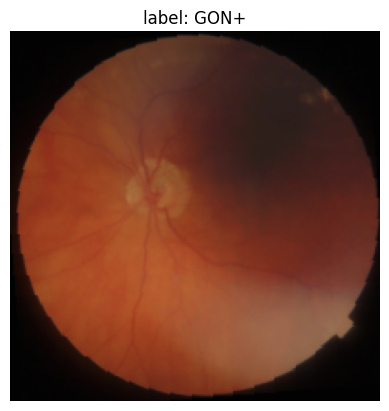

In [2]:
# get a single sample
img_tensor, label = train_dataset[0]   
img = img_tensor.permute(1,2,0).cpu().numpy()  
img = img * IMAGENET_STD + IMAGENET_MEAN
img = img.clip(0,1)

plt.imshow(img)
plt.title(f"label: {train_dataset.classes[label]}")
plt.axis('off')
plt.show()

Initialise model & train script

In [3]:
model = timm.create_model(MODEL, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

def train_one_epoch(model, criterion, optimizer, dataloader):
    model.train()  # Set train mode
    running_loss = 0.0
    running_corrects = 0

    # Loop all batches
    for inputs, labels in dataloader:
        # Set device
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(1), labels.float())

        # Backward pass and update weights
        optimizer.zero_grad() # Clear old gradients
        loss.backward()       # Calculate new gradients
        optimizer.step()      # Update model weights

        # Statistics
        preds = outputs.squeeze(1) > 0.0
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

def validate_one_epoch(model, criterion, dataloader):
    model.eval()   # Set eval mode
    running_loss = 0.0
    running_corrects = 0

    # No need to track gradients for validation loop
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(1), labels.float())
            preds = outputs.squeeze(1) > 0.0
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

Run training

In [37]:
print("Model training commences...\n")

# Save model
BEST_PATH = 'best_model.pth'
LAST_PATH = 'last_model.pth'

# placeholder best val loss value
best_val_loss = float('inf')


for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 30)

    # One train per epoch
    train_loss, train_acc = train_one_epoch(model, criterion, optimizer, train_loader)
    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")

    # One val per epoch
    val_loss, val_acc = validate_one_epoch(model, criterion, val_loader)
    print(f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}\n")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        print(f"🌟 Val loss decreased ({best_val_loss:.4f} --> {val_loss:.4f}). Saving model...")
        torch.save(model.state_dict(), BEST_PATH)
        print(f"Best model saved to {BEST_PATH}\n")
        best_val_loss = val_loss


print("\nTraining complete!")
torch.save(model.state_dict(), LAST_PATH)
print(f"Last model saved to {LAST_PATH}")

Model training commences...

Epoch 1/15
------------------------------
Train Loss: 0.4688 Acc: 0.7577
Val Loss: 0.2552 Acc: 0.9394

🌟 Val loss decreased (inf --> 0.2552). Saving model...
Best model saved to best_model.pth

Epoch 2/15
------------------------------
Train Loss: 0.1815 Acc: 0.9480
Val Loss: 0.1042 Acc: 0.9697

🌟 Val loss decreased (0.2552 --> 0.1042). Saving model...
Best model saved to best_model.pth

Epoch 3/15
------------------------------
Train Loss: 0.1215 Acc: 0.9577
Val Loss: 0.1221 Acc: 0.9545

Epoch 4/15
------------------------------
Train Loss: 0.0820 Acc: 0.9707
Val Loss: 0.1408 Acc: 0.9318

Epoch 5/15
------------------------------
Train Loss: 0.1108 Acc: 0.9659
Val Loss: 0.1419 Acc: 0.9621

Epoch 6/15
------------------------------
Train Loss: 0.0809 Acc: 0.9756
Val Loss: 0.0946 Acc: 0.9848

🌟 Val loss decreased (0.1042 --> 0.0946). Saving model...
Best model saved to best_model.pth

Epoch 7/15
------------------------------
Train Loss: 0.0867 Acc: 0.9740
V

View performance

Metrics for model

--- Ranking Metrics ---
Accuracy: 0.9773
AUROC:  0.9963
PR-AUC: 0.9909

--- Classification Report ---
              precision    recall  f1-score   support

        GON+       0.98      0.99      0.98        99
        GON-       0.97      0.94      0.95        33

    accuracy                           0.98       132
   macro avg       0.97      0.96      0.97       132
weighted avg       0.98      0.98      0.98       132


--- Confusion Matrix ---


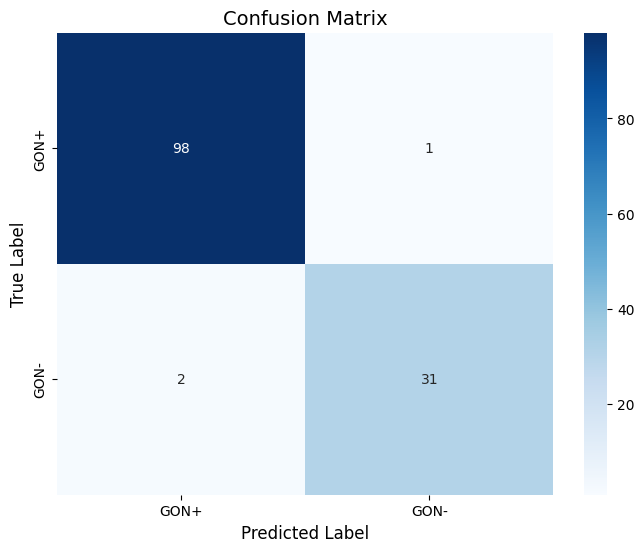

In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

MODEL_PATH = 'models/our_uncropped_model.pth'

def show_metrics(path):
    print("Metrics for model")
    model = timm.create_model("resnet18", pretrained=False, num_classes=NUM_CLASSES)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)

            probs = torch.sigmoid(outputs.squeeze(1))

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    # Concatenate pred from all batches
    all_probs = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)
    all_preds = (all_probs > 0.5).int()


    # Generate AUROC and PR-AUC score
    accuracy = accuracy_score(all_labels.numpy(), all_preds.numpy())
    auroc = roc_auc_score(all_labels.numpy(), all_probs.numpy())
    pr_auc = average_precision_score(all_labels.numpy(), all_probs.numpy())

    print("\n--- Ranking Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUROC:  {auroc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    # Generate and print reports
    class_names = val_dataset.classes
    print("\n--- Classification Report ---")
    print(classification_report(all_labels.numpy(), all_preds.numpy(), target_names=class_names))

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title("Confusion Matrix", fontsize=14)
    plt.show()

show_metrics(MODEL_PATH)

Grad-CAM

Predicted Class: 0
Probability: 0.9938


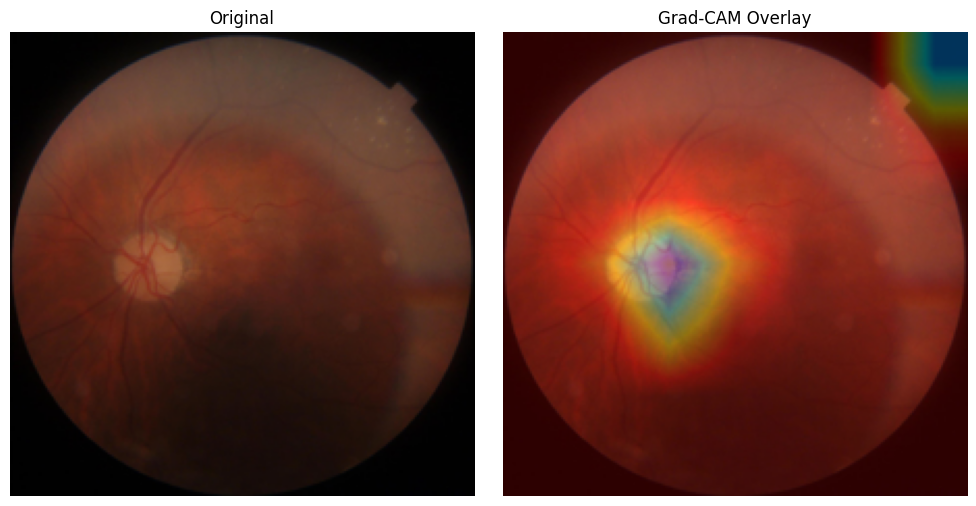

In [5]:
import torch
import torch.nn.functional as F
import timm
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# ---------------------------
# 1. Load model
# ---------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = "resnet18"
NUM_CLASSES = 1
BEST_PATH = "models/our_uncropped_model.pth"
TEST_IMAGE = "ablation/5_0.jpg"
# TEST_IMAGE = "ablation/5_0_masked_b.jpg"    #<---- Uncomment to test ablation

model = timm.create_model(MODEL, pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# ---------------------------
# 2. Hook storage
# ---------------------------
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

# ---------------------------
# 3. Choose target layer
# ---------------------------
target_layer = model.layer4  # last conv block for ResNet

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# ---------------------------
# 4. Preprocess image
# ---------------------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img = Image.open(TEST_IMAGE).convert("RGB")
input_tensor = transform(img).unsqueeze(0)

# ---------------------------
# 5. Forward pass
# ---------------------------
output = model(input_tensor)
pred_class = output.argmax(dim=1)

# Get probability score
with torch.no_grad():
    probability = torch.sigmoid(output.squeeze()).item()  # For binary classification
    # OR if multi-class:
    # probability = torch.softmax(output, dim=1)[0, pred_class].item()

print(f"Predicted Class: {pred_class.item()}")
print(f"Probability: {1 - probability:.4f}")

# ---------------------------
# 6. Backward pass
# ---------------------------
model.zero_grad()
output[0, pred_class].backward()

# ---------------------------
# 7. Compute Grad-CAM
# ---------------------------
grads = gradients[0]           # [C, H, W]
acts = activations[0].squeeze()  # [C, H, W]

weights = grads.mean(dim=(1, 2))  # global avg pool
weights = torch.abs(weights)

cam = torch.zeros(acts.shape[1:], dtype=torch.float32)

for i, w in enumerate(weights):
    cam += w * acts[i]

cam = torch.abs(cam)

cam_min = cam.min()
cam_max = cam.max()

if cam_max - cam_min == 0:
    cam = torch.zeros_like(cam)
else:
    cam = (cam - cam_min) / (cam_max - cam_min)

cam = cam.detach().cpu().numpy()

# ---------------------------
# 8. Overlay heatmap
# ---------------------------
img_np = np.array(img.resize((224, 224)))
heatmap = np.nan_to_num(cam)  # kills NaN / inf
heatmap = np.clip(heatmap, 0, 1)
heatmap = cv2.resize(cam, (224, 224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = heatmap * 0.35 + img_np

# ---------------------------
# 9. Show result
# ---------------------------
# Ensure overlay is uint8
overlay_uint8 = overlay.astype(np.uint8)
original_uint8 = np.array(img.resize((224, 224)))

# Create side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
axes[0].imshow(original_uint8)
axes[0].set_title("Original")
axes[0].axis("off")

# Grad-CAM overlay
axes[1].imshow(overlay_uint8)
axes[1].set_title("Grad-CAM Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Training was repeated with ROI cropped & ROI masked dataset
Run YOLO cropping script before proceeding

#### Performance metrics for ROI cropped dataset

In [6]:
TRAIN_PATH = "image_cropped/train"
TEST_PATH = "image_cropped/test"

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(TEST_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Metrics for model

--- Ranking Metrics ---
Accuracy: 0.8788
AUROC:  0.9232
PR-AUC: 0.8661

--- Classification Report ---
              precision    recall  f1-score   support

        GON+       0.92      0.92      0.92        99
        GON-       0.76      0.76      0.76        33

    accuracy                           0.88       132
   macro avg       0.84      0.84      0.84       132
weighted avg       0.88      0.88      0.88       132


--- Confusion Matrix ---


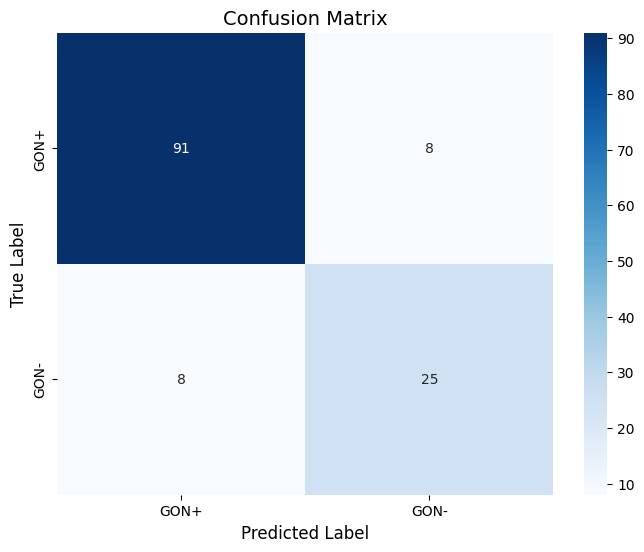

In [7]:
MODEL_PATH = 'models/our_cropped_model.pth'

show_metrics(MODEL_PATH)

#### Performance metrics for ROI masked dataset

In [8]:
TRAIN_PATH = "image_masked/train"
TEST_PATH = "image_masked/test"

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(TEST_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Metrics for model

--- Ranking Metrics ---
Accuracy: 0.9621
AUROC:  0.9942
PR-AUC: 0.9845

--- Classification Report ---
              precision    recall  f1-score   support

        GON+       0.96      0.99      0.98        99
        GON-       0.97      0.88      0.92        33

    accuracy                           0.96       132
   macro avg       0.96      0.93      0.95       132
weighted avg       0.96      0.96      0.96       132


--- Confusion Matrix ---


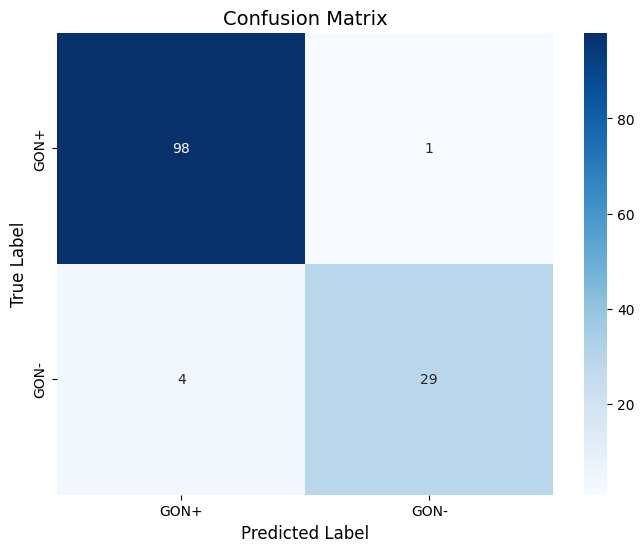

In [9]:
MODEL_PATH = 'models/our_masked_model.pth'

show_metrics(MODEL_PATH)